In [2]:
import numpy as np
from scipy import signal, linalg, optimize
from scipy.special import factorial
from typing import Tuple, Optional, Literal

In [ ]:
"""
Post-processing tools to recover an unsmeared beta spectrum from a
measurement taken through a thin window (e.g. Cs-137 through aluminized
Mylar on a magnetic spectrometer).

Physics background
------------------
The measured spectrum M(T) is the convolution of the true spectrum S(T)
with the window smearing kernel K(ΔT):

    M(T) = ∫ K(T - T') S(T') dT'

K is dominated by the Landau distribution of ionisation energy losses,
plus a Gaussian component from angular/resolution effects.
Key features of K:
  - asymmetric: long tail toward large losses (rare hard collisions)
  - most-probable loss Δ_mp < mean loss <Δ>
  - width ξ ∝ areal density t  (g/cm²)

Three deconvolution strategies are provided, in order of sophistication:

  1. Wiener filter         – fast, optimal in MSE sense for stationary noise
  2. Richardson-Lucy (RL) – iterative, preserves positivity, handles
                            Poisson statistics naturally
  3. Tikhonov (L-curve)   – least-squares with 2nd-derivative smoothness
                            penalty; regularisation chosen automatically

A Landau kernel builder and a simple Gaussian kernel are also provided.
"""

def landau_kernel(
    energy_axis: np.ndarray,
    xi: float,
    delta_mp: float,
    gaussian_sigma: float = 0.0,
) -> np.ndarray:
    """
    Build a normalised smearing kernel appropriate for a thin window.

    The kernel is the Landau distribution (energy-loss straggling) optionally
    convolved with a Gaussian (detector resolution, angular straggling).

    Parameters
    ----------
    energy_axis : 1-D array, keV
        The energy *loss* axis, centred on 0.  Typically spans something like
        [-5*xi, 20*xi] to capture the Landau tail.  Must be uniformly spaced.
    xi : float, keV
        Landau scale parameter:  ξ = 0.1536 · (Z/A) · (ρt / β²)  [keV·cm²/g]
        where ρt is the areal density in g/cm².  For relativistic electrons
        (β~1) and aluminium (Z/A≈0.482), ξ ≈ 0.074 · (ρt) keV·cm²/g.
    delta_mp : float, keV
        Most-probable energy loss.  Positive means a shift toward lower
        measured energy (losses shift the spectrum left).
        Rough formula for relativistic electrons:
            Δ_mp ≈ ξ · [ln(2·m_e·c²·β²·γ²·ξ / I²) + 0.2 - β²]
        where I is the mean excitation energy of the window material.
    gaussian_sigma : float, keV  (optional)
        Additional Gaussian broadening (detector resolution, etc.).

    Returns
    -------
    kernel : 1-D array, same length as energy_axis
        Normalised kernel (sums to 1).
    """
    # Vavilov / Landau PDF via the standard series approximation
    # (Moyal approximation – accurate for ξ small compared to T)
    dE = energy_axis - delta_mp
    lam = (dE - xi * np.log(xi)) / xi          # reduced variable

    # Moyal approximation to Landau:
    # f(λ) = (1/√2π) · exp[-(λ + e^{-λ})/2]
    kernel = np.exp(-0.5 * (lam + np.exp(-lam))) / np.sqrt(2 * np.pi)
    kernel = np.where(np.isfinite(kernel), kernel, 0.0)

    # Optional Gaussian convolution
    if gaussian_sigma > 0.0:
        step = energy_axis[1] - energy_axis[0]
        gauss_axis = np.arange(-4 * gaussian_sigma,
                               4 * gaussian_sigma + step, step)
        gauss = np.exp(-0.5 * (gauss_axis / gaussian_sigma) ** 2)
        gauss /= gauss.sum()
        kernel = np.convolve(kernel, gauss, mode='same')

    # Normalise
    norm = kernel.sum()
    if norm > 0:
        kernel /= norm
    return kernel


def gaussian_kernel(size: int, sigma_bins: float) -> np.ndarray:
    """
    Simple symmetric Gaussian kernel of *size* bins and std *sigma_bins*.
    Useful for testing or when only resolution broadening matters.
    """
    x = np.arange(size) - size // 2
    k = np.exp(-0.5 * (x / sigma_bins) ** 2)
    k /= k.sum()
    return k


def build_convolution_matrix(kernel: np.ndarray, n: int) -> np.ndarray:
    """
    Build the n×n Toeplitz convolution matrix A such that
    M = A @ S  (both as column vectors).

    The kernel is assumed to be centred (peak at kernel.size//2).
    Boundary handling: zero-pad (no wrap-around).
    """
    mid = len(kernel) // 2
    first_col = np.zeros(n)
    first_row = np.zeros(n)
    klen = len(kernel)
    for i in range(klen):
        shift = i - mid
        if 0 <= shift < n:
            first_row[shift] = kernel[i]
        if 0 <= -shift < n:
            first_col[-shift] = kernel[i]
    return linalg.toeplitz(first_col, first_row)

def wiener_deconvolve(
    measured: np.ndarray,
    kernel: np.ndarray,
    snr: float = 100.0,
) -> np.ndarray:
    """
    Wiener-filter deconvolution in the Fourier domain.

    Optimal in the MSE sense when signal and noise are stationary.
    Very fast (two FFTs).  Can produce small negative artefacts near
    sharp features because it has no positivity constraint.

    Parameters
    ----------
    measured : 1-D array
        The smeared, measured spectrum (counts per channel).
    kernel : 1-D array
        The smearing kernel, same length as *measured* or shorter.
        Will be zero-padded to match.
    snr : float
        Assumed signal-to-noise ratio (power ratio).  Acts as the
        regularisation parameter: higher → less smoothing, more noise
        amplification.  A good starting guess is sqrt(total_counts).

    Returns
    -------
    recovered : 1-D array
        Deconvolved spectrum.  May contain small negative values; clip
        if physical positivity is required.
    """
    n = len(measured)
    # Zero-pad kernel to match spectrum length
    k_padded = np.zeros(n)
    mid_k = len(kernel) // 2
    mid_n = n // 2
    start = mid_n - mid_k
    end = start + len(kernel)
    if start < 0 or end > n:
        raise ValueError("Kernel longer than spectrum – reduce kernel size.")
    k_padded[start:end] = kernel

    M = np.fft.rfft(measured)
    K = np.fft.rfft(k_padded)

    # Wiener filter:  Ŝ(f) = M(f) · K*(f) / (|K(f)|² + 1/SNR)
    K_conj = np.conj(K)
    denom = np.abs(K) ** 2 + 1.0 / snr
    S_hat = M * K_conj / denom

    recovered = np.fft.irfft(S_hat, n=n)
    return recovered

def richardson_lucy(
    measured: np.ndarray,
    kernel: np.ndarray,
    n_iter: int = 200,
    convergence_tol: float = 1e-6,
    background: float = 0.0,
) -> Tuple[np.ndarray, int]:
    """
    Richardson-Lucy iterative deconvolution.

    Derived from maximum-likelihood estimation under Poisson statistics –
    the natural noise model for counting experiments.  Guarantees
    positivity.  Converges to the ML estimate; stop early to regularise
    (early stopping = implicit regularisation).

    Algorithm
    ---------
        S^{k+1}_j = S^k_j · Σ_i [ K_{ij} · M_i / (K @ S^k)_i ]
                                  ----------------------------------
                                       Σ_i K_{ij}

    Parameters
    ----------
    measured : 1-D array
        Smeared counts (must be ≥ 0).
    kernel : 1-D array
        Normalised smearing kernel (same length or shorter).
    n_iter : int
        Maximum number of iterations.
    convergence_tol : float
        Stop when relative change in spectrum < tol.
    background : float
        Known uniform background level (counts/bin) to subtract before
        deconvolution.

    Returns
    -------
    recovered : 1-D array  (counts, non-negative)
    n_iterations_run : int
    """
    n = len(measured)
    m = np.maximum(measured - background, 0.0)  # ensure non-negative

    # Build full convolution matrix for forward / backward steps
    A = build_convolution_matrix(kernel, n)       # forward:  M = A @ S
    AT = A.T                                       # backward (adjoint)

    # Initialise with measured spectrum (reasonable starting point)
    S = m.copy() + 1e-6    # avoid division by zero

    # Pre-compute column sums of A (= AT @ ones) for normalisation
    col_sums = AT @ np.ones(n)
    col_sums = np.where(col_sums > 0, col_sums, 1.0)

    prev_S = S.copy()
    for iteration in range(n_iter):
        # Forward project
        M_est = A @ S + 1e-12          # avoid 0/0
        # Ratio of data to estimate
        ratio = m / M_est
        # Back-project and update
        S = S * (AT @ ratio) / col_sums
        S = np.maximum(S, 0.0)         # enforce positivity

        # Convergence check
        change = np.max(np.abs(S - prev_S)) / (np.max(S) + 1e-12)
        if change < convergence_tol:
            return S, iteration + 1
        prev_S = S.copy()

    return S, n_iter

def tikhonov_deconvolve(
    measured: np.ndarray,
    kernel: np.ndarray,
    lam: Optional[float] = None,
    find_lambda: bool = True,
) -> Tuple[np.ndarray, float]:
    """
    Tikhonov (2nd-order) regularised deconvolution.

    Minimises:
        ||A·S - M||² + λ·||L·S||²

    where L is the second-difference (curvature) matrix – penalising
    rapidly oscillating solutions.  This is equivalent to a smoothness
    prior on S.

    If *find_lambda* is True, the optimal λ is chosen via the L-curve
    criterion (corner of the log||residual|| vs log||solution norm|| curve).

    Parameters
    ----------
    measured : 1-D array
        Smeared counts.
    kernel : 1-D array
        Normalised smearing kernel.
    lam : float or None
        Regularisation strength.  If None and find_lambda=True, it is
        chosen automatically.  Larger λ → smoother solution.
    find_lambda : bool
        Whether to run the L-curve search.

    Returns
    -------
    recovered : 1-D array
    lam_used : float
        The regularisation parameter that was used.
    """
    n = len(measured)
    A = build_convolution_matrix(kernel, n)

    # Second-difference matrix L  (curvature penalty)
    diags = np.array([1, -2, 1])
    L = np.zeros((n - 2, n))
    for i in range(n - 2):
        L[i, i:i + 3] = diags

    def solve(lam_val: float) -> np.ndarray:
        # Normal equations:  (AᵀA + λ·LᵀL) S = Aᵀ M
        ATA = A.T @ A
        LTL = L.T @ L
        rhs = A.T @ measured
        S = linalg.solve(ATA + lam_val * LTL, rhs, assume_a='sym')
        return np.maximum(S, 0.0)

    if lam is not None:
        return solve(lam), lam

    if find_lambda:
        # L-curve: sweep λ, find corner by maximum curvature
        lambdas = np.logspace(-4, 4, 60)
        residuals = []
        norms = []
        for lv in lambdas:
            S = solve(lv)
            residuals.append(np.log(np.linalg.norm(A @ S - measured)))
            norms.append(np.log(np.linalg.norm(L @ S)))

        residuals = np.array(residuals)
        norms = np.array(norms)

        # Curvature of the L-curve (parametric, normalised)
        # κ = (x'y'' - y'x'') / (x'² + y'²)^(3/2)
        dx = np.gradient(residuals)
        dy = np.gradient(norms)
        ddx = np.gradient(dx)
        ddy = np.gradient(dy)
        curvature = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2 + 1e-20) ** 1.5
        best_idx = np.argmax(curvature)
        lam_opt = lambdas[best_idx]
    else:
        lam_opt = 1.0   # fallback default

    return solve(lam_opt), lam_opt

def bootstrap_uncertainty(
    measured: np.ndarray,
    kernel: np.ndarray,
    method: Literal['rl', 'wiener', 'tikhonov'] = 'rl',
    n_bootstrap: int = 200,
    **method_kwargs,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Estimate channel-by-channel uncertainty on the deconvolved spectrum
    by Poisson bootstrapping the measured counts.

    Parameters
    ----------
    measured : 1-D array  (counts, must be integer-like)
    kernel   : 1-D array
    method   : which deconvolution to use per resample
    n_bootstrap : number of resamples

    Returns
    -------
    mean_spectrum : 1-D array
    std_spectrum  : 1-D array  (1σ uncertainty per bin)
    """
    results = []
    for _ in range(n_bootstrap):
        # Poisson resample
        m_resamp = np.random.poisson(np.maximum(measured, 0).astype(float))
        if method == 'rl':
            s, _ = richardson_lucy(m_resamp, kernel, **method_kwargs)
        elif method == 'wiener':
            s = wiener_deconvolve(m_resamp, kernel, **method_kwargs)
        elif method == 'tikhonov':
            s, _ = tikhonov_deconvolve(m_resamp, kernel, **method_kwargs)
        else:
            raise ValueError(f"Unknown method '{method}'")
        results.append(s)

    results = np.array(results)
    return results.mean(axis=0), results.std(axis=0)

def deconvolve_beta_spectrum(
    measured: np.ndarray,
    energy_keV: np.ndarray,
    areal_density_mg_cm2: float,
    window_material: Literal['Al', 'Mylar', 'Be'] = 'Mylar',
    method: Literal['rl', 'wiener', 'tikhonov', 'all'] = 'rl',
    rl_iterations: int = 300,
    wiener_snr: Optional[float] = None,
    tikhonov_lam: Optional[float] = None,
    gaussian_sigma_keV: float = 0.5,
) -> dict:
    """
    High-level wrapper: build the physically motivated Landau kernel for a
    given window and apply the chosen deconvolution method(s).

    Parameters
    ----------
    measured : 1-D array
        Measured counts per energy bin.
    energy_keV : 1-D array
        Bin centre energies in keV (uniformly spaced).
    areal_density_mg_cm2 : float
        Window areal density in mg/cm².  Typical aluminized Mylar: 1–5 mg/cm².
    window_material : 'Al', 'Mylar', or 'Be'
        Sets Z, A, I (mean excitation energy) for the Bethe formula.
    method : 'rl', 'wiener', 'tikhonov', or 'all'
        Which deconvolution method(s) to run.
    rl_iterations : int
        Max R-L iterations.
    wiener_snr : float or None
        SNR for Wiener filter.  Defaults to sqrt(total counts).
    tikhonov_lam : float or None
        Regularisation for Tikhonov.  None → L-curve search.
    gaussian_sigma_keV : float
        Extra Gaussian broadening (detector resolution).

    Returns
    -------
    dict with keys:
        'kernel'         – the smearing kernel used
        'energy_loss_axis' – keV axis for the kernel
        'rl'             – (recovered, n_iter) if method in ('rl','all')
        'wiener'         – recovered array if method in ('wiener','all')
        'tikhonov'       – (recovered, lam) if method in ('tikhonov','all')
        'xi_keV'         – Landau scale parameter used
        'delta_mp_keV'   – most-probable loss used
    """
    # Material parameters  (Z, A, I in eV)
    materials = {
        'Al':    (13,  26.98,  166.0),
        'Mylar': (6.4, 12.85,  78.7),   # effective for C₁₀H₈O₄
        'Be':    (4,   9.012,  63.7),
    }
    Z, A_mass, I_eV = materials[window_material]

    # Areal density in g/cm²
    t = areal_density_mg_cm2 * 1e-3   # g/cm²

    # Approximate β for Cs-137 betas (use 400 keV as representative energy)
    T_ref_keV = 400.0
    m_e_keV = 511.0
    gamma = 1.0 + T_ref_keV / m_e_keV
    beta2 = 1.0 - 1.0 / gamma ** 2

    # Landau scale parameter ξ (keV)
    # 0.1536 MeV·cm²/g is the Bethe coefficient; multiply by 1000 → keV
    xi = 0.1536 * 1000.0 * (Z / A_mass) * t / beta2   # keV

    # Most-probable loss (approximate relativistic formula)
    I_keV = I_eV * 1e-3
    ln_arg = 2 * m_e_keV * beta2 * gamma**2 * xi / I_keV**2
    if ln_arg > 0:
        delta_mp = xi * (np.log(ln_arg) + 0.2 - beta2)
    else:
        delta_mp = xi

    delta_mp = max(delta_mp, 0.1 * xi)   # physical floor

    # Energy loss axis for the kernel
    step = energy_keV[1] - energy_keV[0]
    loss_max = max(20 * xi, 5 * step)
    loss_axis = np.arange(-3 * xi, loss_max, step)

    kernel = landau_kernel(loss_axis, xi, delta_mp, gaussian_sigma_keV)

    # Trim kernel to a manageable size (keep >0.01% of peak)
    thresh = 1e-4 * kernel.max()
    nonzero = np.where(kernel > thresh)[0]
    if len(nonzero) > 0:
        kernel = kernel[nonzero[0]:nonzero[-1] + 1]

    # Make kernel length odd for symmetrical zero-padding
    if len(kernel) % 2 == 0:
        kernel = np.append(kernel, 0.0)
    kernel /= kernel.sum()

    result = {
        'kernel': kernel,
        'energy_loss_axis': loss_axis,
        'xi_keV': xi,
        'delta_mp_keV': delta_mp,
    }

    snr = wiener_snr or float(np.sqrt(np.sum(measured) + 1))

    if method in ('rl', 'all'):
        rec, n_it = richardson_lucy(measured, kernel, n_iter=rl_iterations)
        result['rl'] = (rec, n_it)

    if method in ('wiener', 'all'):
        rec = wiener_deconvolve(measured, kernel, snr=snr)
        result['wiener'] = rec

    if method in ('tikhonov', 'all'):
        rec, lam_used = tikhonov_deconvolve(measured, kernel, tikhonov_lam)
        result['tikhonov'] = (rec, lam_used)

    return result

'\n# ---------------------------------------------------------------------------\n# 7.  DEMO / SELF-TEST\n# ---------------------------------------------------------------------------\n\nif __name__ == \'__main__\':\n    import matplotlib.pyplot as plt\n\n    rng = np.random.default_rng(42)\n\n    # --- Synthetic Cs-137 spectrum ---\n    E = np.linspace(0, 700, 1400)   # keV, 0.5 keV/bin\n    step = E[1] - E[0]\n\n    # Beta continuum (allowed shape ~ p·E_e · (Q-T)² · F(Z,T))\n    Q = 512.0\n    true_spectrum = np.zeros_like(E)\n    beta_region = E < Q\n    T = E[beta_region]\n    p = np.sqrt(T**2 + 2 * T * 511.0)   # momentum proxy\n    true_spectrum[beta_region] = p * (T + 511.0) * (Q - T)**2\n    true_spectrum[beta_region] *= (1 + 0.01 * 13 / (T + 1))  # crude Fermi factor\n\n    # Internal conversion lines at 624 and 656 keV\n    for E_line, amp in [(624.0, 3e7), (656.0, 1e7)]:\n        sigma_line = 1.5  # keV (intrinsic width)\n        true_spectrum += amp * np.exp(-0.5 * ((E - E_

In [3]:
import pandas as pd

In [6]:
spectra_df = pd.read_csv("D:/brs/brs_overnight3_100mVtrigger.csv")
spectra_df.head()

,Scan,Direction,Measured_Current_A,Counts,Temperature_C,Timestamp
0,1,up,-0.000014,454,20.00,12:58:08.653
1,1,up,0.008258,480,20.00,12:58:59.631
2,1,up,0.018341,479,14.75,12:59:50.661
3,1,up,0.028471,510,14.76,13:00:41.668
4,1,up,0.038549,477,14.69,13:01:32.655


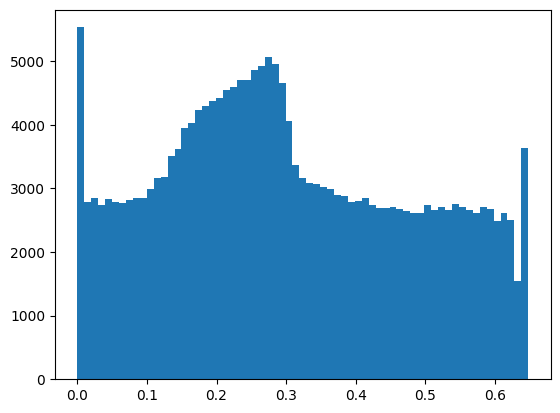

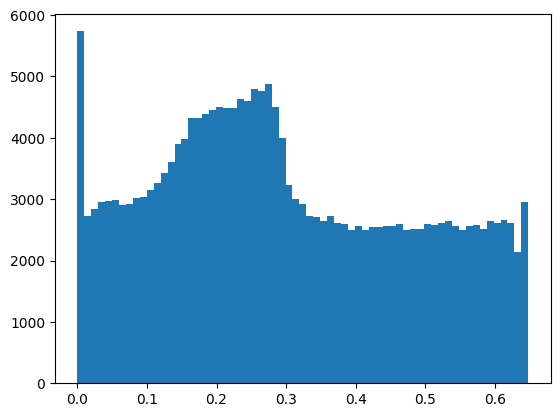

In [27]:
def beta_spectrum_analyze(df):
    # Filter the dataframe
    up_rows = df[df['Direction'] == "up"]
    down_rows = df[df['Direction'] == "down"]
    
    # Use np.repeat for high-speed array expansion
    # This repeats 'Real_Current_A' the number of times specified in 'Counts'
    up_array = np.repeat(up_rows['Measured_Current_A'].values, up_rows['Counts'].values)
    down_array = np.repeat(down_rows['Measured_Current_A'].values, down_rows['Counts'].values)
    
    return up_array, down_array

up_sum, down_sum = beta_spectrum_analyze(spectra_df)
plt.hist(up_sum, bins=65)
plt.show()
plt.hist(down_sum, bins=65)
plt.show()

In [16]:
def beta_add_up_down_curves(upx, upy, downx, downy):
    """
    Corrects for magnetic hysteresis by shifting and averaging 'up' and 'down' 
    current scans to produce a single compensated spectrum.
    
    Args:
        upx, upy (array-like): Bin numbers (current) and counts for the upward scan.
        downx, downy (array-like): Bin numbers and counts for the downward scan.

    Returns:
        tuple: (xout, yout) where xout is the shifted x-axis (momenta) and 
               yout is the combined/summed count data.
    """
    # Convert to numpy arrays for vector operations
    upx, upy = np.array(upx).flatten(), np.array(upy).flatten()
    downx, downy = np.array(downx).flatten(), np.array(downy).flatten()
    
    # Identify the K-peak index for both directions
    idx_up = np.argmax(upy)
    idx_down = np.argmax(downy)
    
    maxup_x = upx[idx_up]
    maxdwn_x = downx[idx_down]
    
    # Calculate shift amount to align the peaks (midpoint strategy)
    shift_amt = (maxup_x - maxdwn_x) / 2
    
    # Shift the downward scan to the midpoint (goal)
    # The original MATLAB code shifts the vectors to align the datasets
    downx_shifted = downx + shift_amt
    
    # For a combined spectrum, we align the counts (assuming equivalent bin spacing)
    # In practice, you would interpolate; here we return shifted x and summed y
    return downx_shifted, upy + downy

In [34]:
def combine_beta_spectrum(up_sum, down_sum):
    upy, upx = np.histogram(up_sum, bins=65)
    downy, downx = np.histogram(down_sum, bins=65)
    x, new_y = beta_add_up_down_curves(upx, upy, downx, downy)
    centered_x = (x[:-1] + x[1:]) / 2
    width = np.diff(x)
    return centered_x, new_y, width

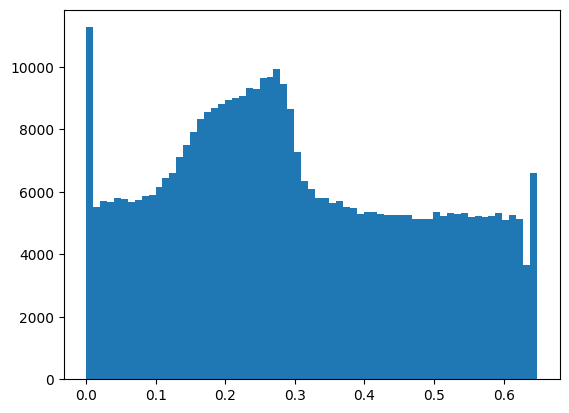

In [35]:
new_x, new_y, width = combine_beta_spectrum(up_sum, down_sum)
plt.bar(new_x, new_y, width=width)
plt.show()

In [44]:
def normalize_beta_spectrum(x, y):
    return np.array(y) / np.array(x)

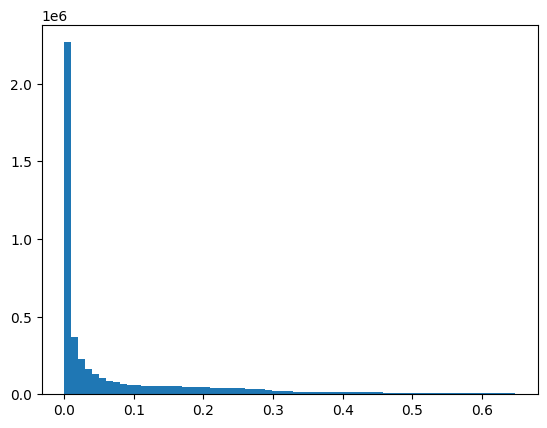

In [52]:
normalized_y = normalize_beta_spectrum(new_x, new_y)
plt.bar(new_x, normalized_y, width=width)
plt.show()

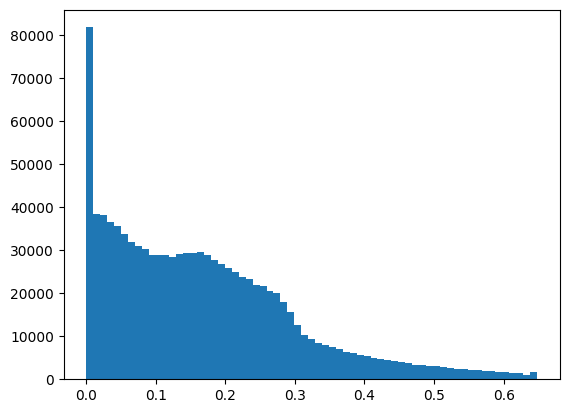

In [56]:
result = deconvolve_beta_spectrum(new_y, new_x, areal_density_mg_cm2=1, method='rl', wiener_snr=np.sqrt(sum(new_y)))
plt.bar(new_x, result["rl"][0], width=width)
plt.show()

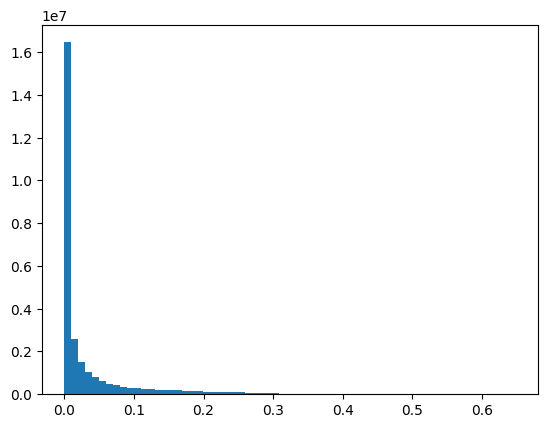

In [58]:
normalized_deconvolved_y = normalize_beta_spectrum(new_x, result["rl"][0])
plt.bar(new_x, normalized_deconvolved_y, width=width)
plt.show()

<BarContainer object of 65 artists>

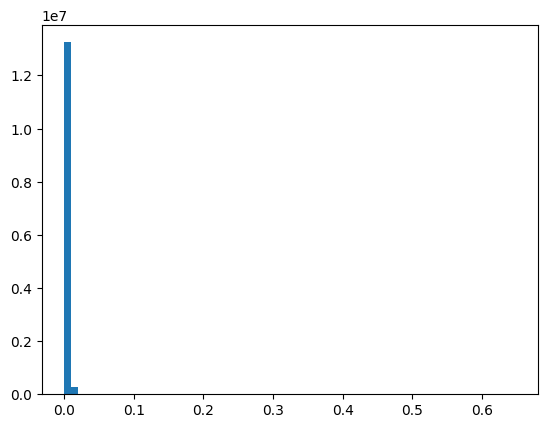

In [ ]:
result = deconvolve_beta_spectrum(normalized_y, new_x, areal_density_mg_cm2=1, )
plt.bar(new_x, result["rl"][0], width=width)
plt.show()